In [ ]:
import math
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import LSTM
from tensorflow.keras.layers import Dropout
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import train_test_split

In [ ]:
df = pd.read_csv("/content/GRU_stock_forecasting_dataset.csv", parse_dates=True)
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2020-01-01,100.29,101.57,99.02,100.00,99.93,3505700
1,2020-01-02,101.78,102.08,99.32,101.07,101.18,1145693
2,2020-01-03,101.34,102.47,98.42,100.87,100.94,2649734
3,2020-01-04,102.29,102.72,101.75,102.26,102.50,13076798
4,2020-01-05,105.12,108.04,103.24,105.46,105.30,10299397


In [ ]:
df.describe()

,Open,High,Low,Close,Adj Close,Volume
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03
mean,141.926790,144.382600,139.491830,141.874070,141.867160,7.838207e+06
std,50.939165,51.841119,50.081971,50.905604,50.909839,4.043220e+06
min,80.820000,81.720000,79.680000,81.310000,81.230000,1.012879e+06
25%,112.427500,113.980000,110.202500,112.367500,112.297500,4.299114e+06
50%,132.515000,134.840000,130.485000,132.395000,132.435000,7.785863e+06
75%,149.277500,152.220000,146.685000,149.045000,148.980000,1.130585e+07
max,312.760000,316.810000,307.720000,313.000000,313.110000,1.499417e+07


In [ ]:
print(df.shape)
df.info()

(1000, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       1000 non-null   object 
 1   Open       1000 non-null   float64
 2   High       1000 non-null   float64
 3   Low        1000 non-null   float64
 4   Close      1000 non-null   float64
 5   Adj Close  1000 non-null   float64
 6   Volume     1000 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 54.8+ KB


<Axes: >

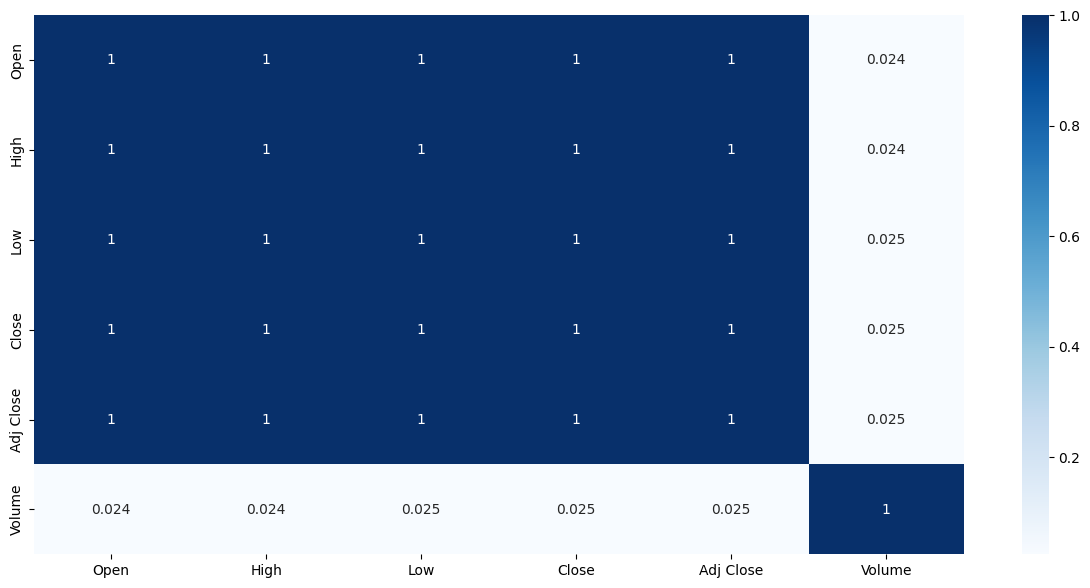

In [ ]:
plt.figure(figsize=(15,7))
sns.heatmap(df.corr(numeric_only=True), cbar=True, annot=True, cmap='Blues')

Text(0, 0.5, 'Close Price USD ($)')

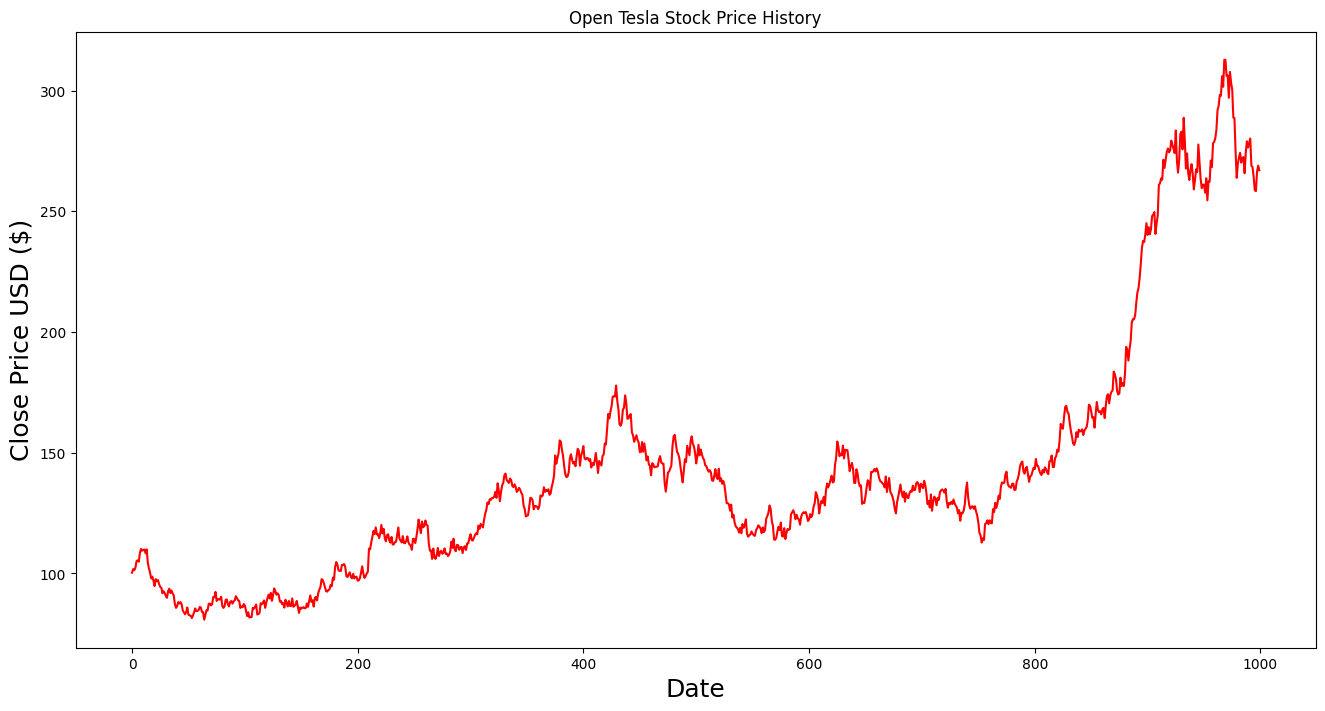

In [ ]:
df["Open"].plot(figsize=(16,8), color='red')
plt.title("Open Tesla Stock Price History")
plt.xlabel("Date", fontsize=18)
plt.ylabel("Close Price USD ($)", fontsize=18)

[ 80.82  81.51  81.72  81.88  82.03  82.34  82.48  82.52  82.67  82.77
  82.9   82.97  83.07  83.16  83.6   83.64  83.88  83.9   83.91  83.94
  83.95  84.06  84.39  84.43  84.58  84.61  84.63  84.76  84.8   85.39
  85.4   85.48  85.54  85.7   85.71  85.72  85.74  85.74  85.74  85.83
  85.84  85.86  85.87  85.9   85.96  85.99  86.    86.08  86.12  86.12
  86.18  86.27  86.32  86.34  86.35  86.39  86.5   86.54  86.54  86.57
  86.68  86.72  86.74  87.07  87.12  87.13  87.15  87.21  87.26  87.27
  87.28  87.31  87.45  87.46  87.47  87.55  87.57  87.62  87.67  87.87
  87.88  87.9   88.1   88.12  88.23  88.26  88.34  88.47  88.56  88.57
  88.58  88.59  88.59  88.6   88.65  88.65  88.77  88.78  88.8   88.88
  88.9   89.03  89.09  89.19  89.24  89.24  89.44  89.62  89.64  89.65
  89.71  89.82  89.91  90.09  90.26  90.3   90.34  90.57  90.59  90.86
  90.88  91.02  91.1   91.17  91.2   91.68  91.77  91.78  91.79  91.8
  91.88  91.95  92.35  92.47  92.61  92.62  92.66  92.66  92.94  93.1
  93.26 

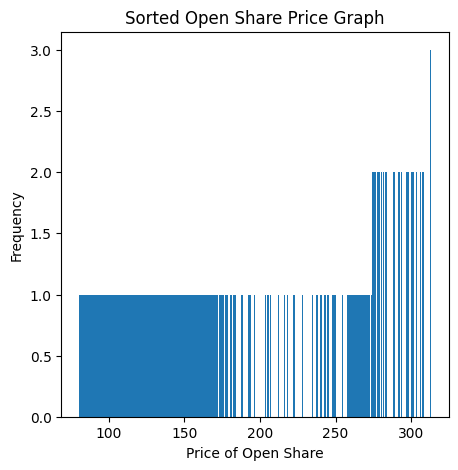

In [ ]:
print(np.sort(df['Open']), "This is the Sorted data of Open Share Price")

plt.figure(figsize=(5,5))

plt.bar(
    list(np.sort(df['Open'].value_counts().keys())),
    list(np.sort(df['Open'].value_counts()))
)

plt.title("Sorted Open Share Price Graph")
plt.xlabel("Price of Open Share")
plt.ylabel("Frequency")
plt.show()

In [ ]:
df.isna().any()

,0
Date,False
Open,False
High,False
Low,False
Close,False
Adj Close,False
Volume,False


In [ ]:
dataset = df["Open"]
dataset = pd.DataFrame(dataset)

data= dataset.values

data.shape

(1000, 1)

In [ ]:
scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(data)

In [ ]:
train_size = int(len(data)*.75)
test_size = len(data) - train_size

print("Train Size" , train_size, "Test Size",test_size)

train_data = scaled_data[ :train_size, 0:1]
test_data = scaled_data[train_size-60: , 0:1]

Train Size 750 Test Size 250


In [ ]:
train_data.shape,test_data.shape

((750, 1), (310, 1))

In [ ]:
X_train=[]
y_train=[]

for i in range(60, len(train_data)):
  X_train.append(train_data[i-60:i, 0])
  y_train.append(train_data[i, 0])

In [ ]:
X_train, y_train = np.array(X_train), np.array(y_train)

In [ ]:
X_train.shape, y_train.shape

((690, 60), (690,))

In [ ]:
model = Sequential()
model.add(LSTM(50, return_sequences=True, input_shape=(X_train.shape[1], 1)))
model.add(LSTM(64, return_sequences=False))
model.add(Dense(32))
model.add(Dense(16))
model.add(Dense(1))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model.compile(optimizer='adam', loss='mse', metrics = ["mean_squared_error"])

In [ ]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_3 (LSTM)                   │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 64)             │        29,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 42,465 (165.88 KB)

 Trainable params: 42,465 (165.88 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
callbacks = [EarlyStopping(monitor='loss', patience=10, restore_best_weights=True)]
history= model.fit(X_train, y_train, epochs=100, batch_size =32, callbacks=callbacks)

Epoch 1/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 5s 52ms/step - loss: 0.0065 - mean_squared_error: 0.0065
Epoch 2/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - loss: 9.7655e-04 - mean_squared_error: 9.7655e-04
Epoch 3/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - loss: 7.0105e-04 - mean_squared_error: 7.0105e-04
Epoch 4/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 83ms/step - loss: 5.6146e-04 - mean_squared_error: 5.6146e-04
Epoch 5/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - loss: 5.4640e-04 - mean_squared_error: 5.4640e-04
Epoch 6/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - loss: 5.1892e-04 - mean_squared_error: 5.1892e-04
Epoch 7/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - loss: 4.9705e-04 - mean_squared_error: 4.9705e-04
Epoch 8/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - loss: 4.8356e-04 - mean_squared_error: 4.8356e-04
Epoch 9/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - loss: 4.6789e-04 - mean_squared_error: 4.6789e-04
Epoch 10/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - loss: 4.4348e-04 

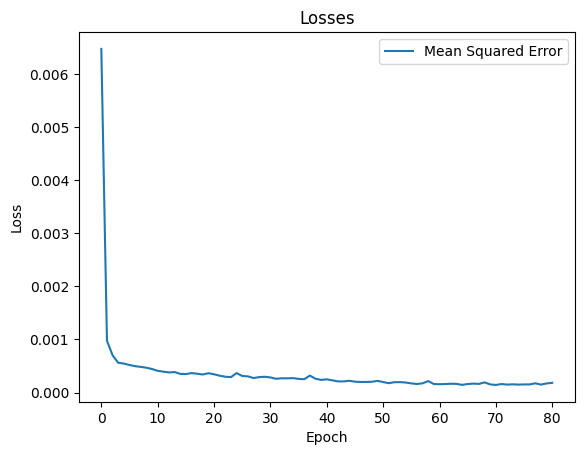

In [ ]:
plt.plot(history.history['loss'])
plt.title(history.history['mean_squared_error'])
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.title("Losses")
plt.legend(['Mean Squared Error','Mean Squared Error'])
plt.show()

In [ ]:
X_test = []
y_test = []

for i in range(60, len(test_data)):
  X_test.append(test_data[i-60:i, 0])
  y_test.append(test_data[i, 0])
X_test, y_test = np.array(X_test), np.array(y_test)
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

In [ ]:
X_test.shape, y_test.shape

((250, 60, 1), (250,))

In [ ]:
prediction = model.predict(X_test)
prediction = scaler.inverse_transform(prediction)
prediction.shape

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 101ms/step


(250, 1)

In [ ]:
y_test = scaler.inverse_transform(y_test.reshape(-1, 1))

RMSE = np.sqrt(np.mean((y_test - prediction) ** 2)).round(2)
RMSE

np.float64(11469479.85)

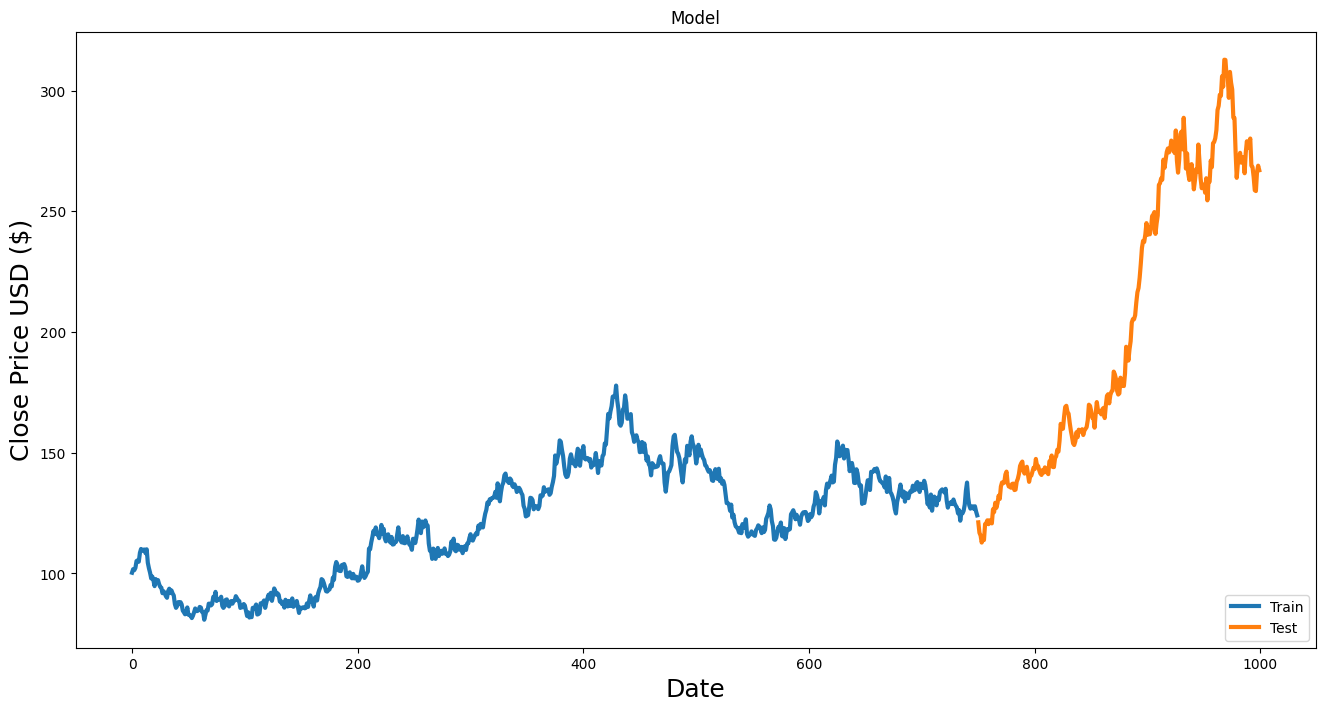

In [ ]:
train = dataset.iloc[:train_size, 0:1]
test = dataset.iloc[train_size:, 0:1]
test['Predictions'] = prediction

plt.figure(figsize=(16,8))
plt.title('Model')
plt.xlabel('Date', fontsize=18)
plt.ylabel('Close Price USD ($)', fontsize=18)
plt.plot(train['Open'],linewidth=3)
plt.plot(test['Open'], linewidth=3)
plt.legend(['Train', 'Test', 'Predictions'], loc='lower right')
plt.show()

In [ ]:
model.save("GRU_stock_forecasting_model.h5")

In [ ]:
from tensorflow.keras.models import load_model

In [ ]:
model.save("GRU_stock_forecasting_model.keras")